# Model performance

Prediction performance of the DeepDanio models on held-out data. Each split model is evaluated on the peaks of its own validation and test chromosomes, which were not used to train it. The test chromosomes of the three splits do not overlap, so their test sets are also combined into a single held-out test set.

Requires the processed and raw scATAC-seq data, downloaded with `data/download_data.py`, and `predictions.h5` in this folder. To generate `predictions.h5` with the predictions of all split models on their validation and test sets, run the following from this folder:

```shell
python predict.py --splits 0 1 2 --subsets val test
```

This requires the model weights, downloaded with `models/download_weights.py`, and takes about a minute on a GPU.

In [1]:
import h5py
import numpy
import pandas
import seaborn
from matplotlib import pyplot

from deepdanio import data, definitions, metrics, plot

## Load data

Measured signal of all peaks, and predictions of each split model on the peaks and negative regions of its validation and test chromosomes. Predictions are stored in `preds[(split, subset, region_group)]` as DataFrames indexed by region ID, with one column per cell state. `split` can also be `'combined'`, for the union of the three splits.

In [2]:
peaks_df, signal_df = data.load_training_data('peaks')
negatives_df, _ = data.load_training_data('negatives')
region_ids = {'peaks': peaks_df.index, 'negatives': negatives_df.index}

preds = {}
with h5py.File('predictions.h5', 'r') as f:
    for split in definitions.DEEPDANIO_SPLITS:
        for subset in ['val', 'test']:
            for region_group in ['peaks', 'negatives']:
                h5_group = f[f'split_{split}/{subset}/{region_group}']
                preds[(split, subset, region_group)] = pandas.DataFrame(
                    h5_group['pred'][:],
                    index=region_ids[region_group][h5_group['idx'][:]],
                    columns=definitions.CELL_STATES,
                )

# Combined held-out sets across splits
for subset in ['val', 'test']:
    for region_group in ['peaks', 'negatives']:
        preds[('combined', subset, region_group)] = pandas.concat(
            [preds[(split, subset, region_group)] for split in definitions.DEEPDANIO_SPLITS]
        )

for subset in ['val', 'test']:
    print(f"{subset}: {len(preds[('combined', subset, 'peaks')]):,} peaks, "
          f"{len(preds[('combined', subset, 'negatives')]):,} negatives")

val: 114,197 peaks, 54,571 negatives
test: 118,310 peaks, 52,356 negatives


## Calculate metrics

Pearson r, Spearman r, and RMSE between measured and predicted signal of peaks, calculated:
- Per cell state, across peaks: how well the model predicts differences in accessibility between peaks in each cell state.
- Per peak, across cell states: how well the model predicts the pattern of accessibility of each peak across cell states.

The table shows the median correlations for the validation and test sets. Plots below use the test sets.

In [3]:
metrics_per_cell_state = {}
metrics_per_peak = {}
for split in definitions.DEEPDANIO_SPLITS + ['combined']:
    for subset in ['val', 'test']:
        pred_df = preds[(split, subset, 'peaks')]
        split_signal_df = signal_df.loc[pred_df.index]
        metrics_per_cell_state[(split, subset)] = metrics.get_regression_metrics(split_signal_df, pred_df, per='cell_state')
        metrics_per_peak[(split, subset)] = metrics.get_regression_metrics(split_signal_df, pred_df, per='region')

# Summary: medians of each metric
summary = []
for (split, subset), metrics_df in metrics_per_cell_state.items():
    peak_metrics_df = metrics_per_peak[(split, subset)]
    summary.append({
        'split': split,
        'subset': subset,
        'n_peaks': len(peak_metrics_df),
        'pearson_r per cell state': metrics_df['pearson_r'].median(),
        'spearman_r per cell state': metrics_df['spearman_r'].median(),
        'pearson_r per peak': peak_metrics_df['pearson_r'].median(),
        'spearman_r per peak': peak_metrics_df['spearman_r'].median(),
    })
summary_df = pandas.DataFrame(summary).set_index(['subset', 'split']).sort_index()
summary_df.round(3)

n_peaks  pearson_r per cell state  spearman_r per cell state  \
subset split                                                                    
test   0           40777                     0.644                      0.555   
       1           40278                     0.651                      0.558   
       2           37255                     0.657                      0.560   
       combined   118310                     0.650                      0.557   
val    0           40278                     0.650                      0.560   
       1           37255                     0.654                      0.558   
       2           36664                     0.599                      0.521   
       combined   114197                     0.634                      0.545   

                 pearson_r per peak  spearman_r per peak  
subset split                                              
test   0                      0.478                0.401  
       1                      0.481                0.404  
       2                      0.487                0.409  
       combined               0.482                0.405  
val    0                      0.480                0.405  
       1                      0.485                0.406  
       2                      0.490                0.415  
       combined               0.485                0.409

## Performance per cell state

Distribution of per-cell-state correlations on the test set of each split and the combined test set. Labels show the median ± interquartile range (IQR).

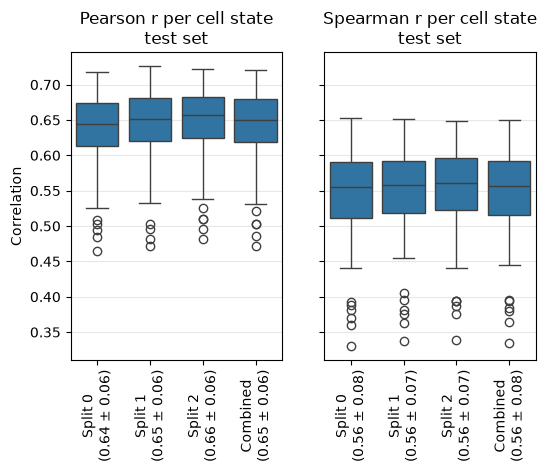

In [4]:
splits_to_plot = definitions.DEEPDANIO_SPLITS + ['combined']
split_names = {split: f'Split {split}' for split in definitions.DEEPDANIO_SPLITS}
split_names['combined'] = 'Combined'

fig, axes = pyplot.subplots(1, 2, figsize=(6, 4), sharey=True)
for ax, metric, metric_label in zip(axes, ['pearson_r', 'spearman_r'], ['Pearson r', 'Spearman r']):
    # Long-format table with one row per split and cell state
    metric_df = pandas.DataFrame({
        split_names[split]: metrics_per_cell_state[(split, 'test')][metric] for split in splits_to_plot
    }).melt(var_name='split', value_name=metric)
    seaborn.boxplot(data=metric_df, x='split', y=metric, ax=ax)

    # Tick labels with median and IQR
    tick_labels = []
    for split in splits_to_plot:
        vals = metrics_per_cell_state[(split, 'test')][metric]
        iqr = vals.quantile(0.75) - vals.quantile(0.25)
        tick_labels.append(f'{split_names[split]}\n({vals.median():.2f} ± {iqr:.2f})')
    ax.set_xticks(range(len(tick_labels)))
    ax.set_xticklabels(tick_labels, rotation=90)
    ax.set_xlabel('')
    ax.set_ylabel('Correlation')
    ax.set_title(f'{metric_label} per cell state\ntest set')
    ax.grid(axis='y', alpha=0.3)
pyplot.show()

Pearson r of each cell state on the combined test set, grouped by stage and colored by lineage.

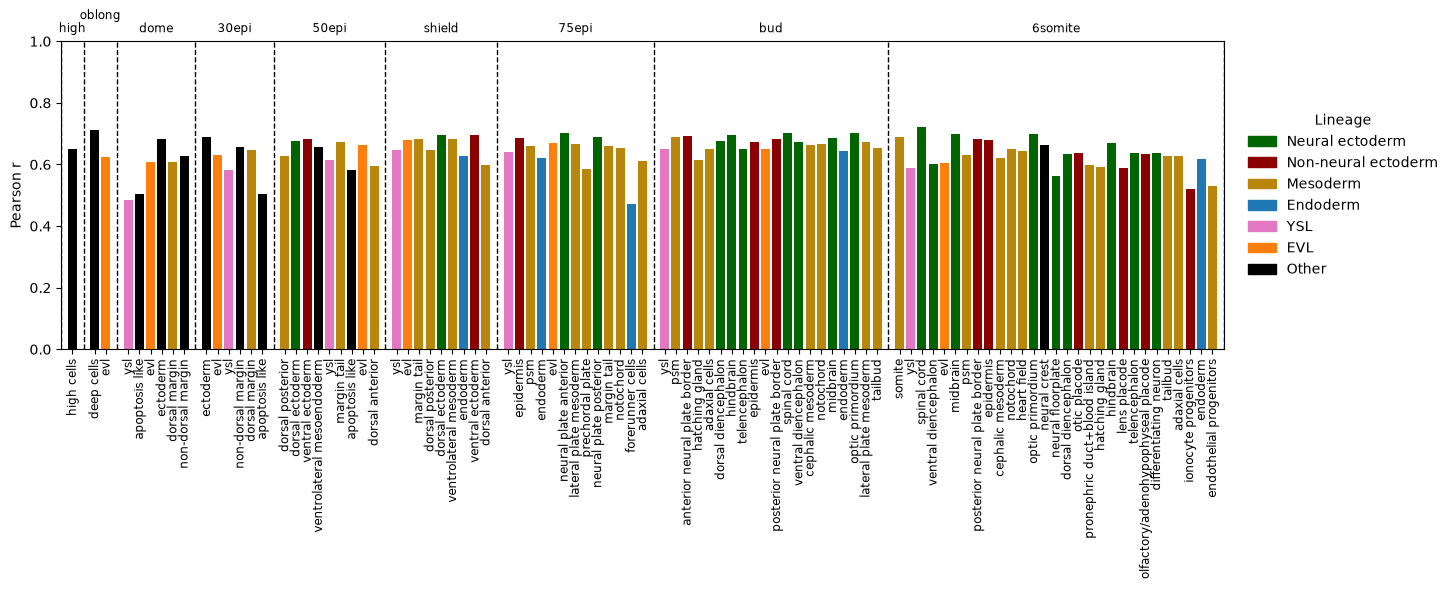

In [5]:
ax = plot.bar(metrics_per_cell_state[('combined', 'test')]['pearson_r'], figsize=(15, 4))
ax.set_ylabel('Pearson r')
ax.set_ylim(0, 1)
pyplot.show()

Measured vs. predicted signal across test peaks for the cell states with the highest, median, and lowest Pearson r. Color indicates the density of peaks.

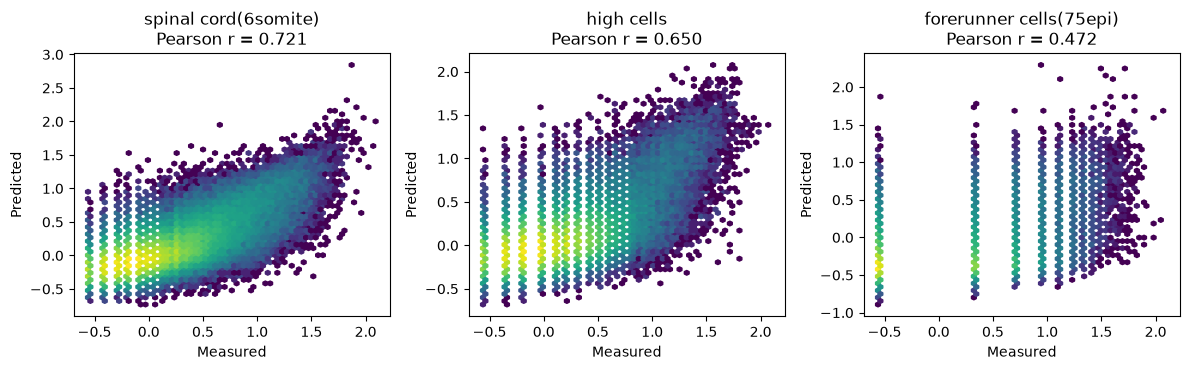

In [6]:
cell_state_metrics_df = metrics_per_cell_state[('combined', 'test')].sort_values('pearson_r')
cell_states_to_plot = [
    cell_state_metrics_df.index[-1],
    cell_state_metrics_df.index[len(cell_state_metrics_df) // 2],
    cell_state_metrics_df.index[0],
]
pred_df = preds[('combined', 'test', 'peaks')]
test_signal_df = signal_df.loc[pred_df.index]

fig, axes = pyplot.subplots(1, 3, figsize=(12, 3.8))
for ax, cell_state in zip(axes, cell_states_to_plot):
    ax.hexbin(test_signal_df[cell_state], pred_df[cell_state], gridsize=60, bins='log', cmap='viridis', mincnt=1)
    ax.set_xlabel('Measured')
    ax.set_ylabel('Predicted')
    ax.set_title(f"{cell_state}\nPearson r = {cell_state_metrics_df.loc[cell_state, 'pearson_r']:.3f}")
fig.tight_layout()
pyplot.show()

### Performance vs. sequencing depth

The number of reads of each cell state is calculated from the raw CPM data. CPM values of a cell state are integer multiples of their minimum nonzero value, which therefore corresponds to a single read, and the number of reads is 10^6 divided by this value. Reads are counted within peaks only, since CPM was calculated over peaks. Cell states with fewer reads also have more peaks with zero reads.

In [7]:
cpm_df = pandas.read_csv(definitions.PEAK_CPM_PATH, sep='\t')
depth_df = pandas.DataFrame({
    'reads_in_peaks': 1e6 / cpm_df.where(cpm_df > 0).min(),
    'frac_zero': (cpm_df == 0).mean(),
})
depth_df.sort_values('reads_in_peaks').head(10)

,reads_in_peaks,frac_zero
endothelial progenitors(6somite),2.165620e+05,0.756709
forerunner cells(75epi),2.443340e+05,0.708638
ionocyte progenitors(6somite),3.576790e+05,0.665899
neural floorplate(6somite),4.402841e+05,0.623826
ysl(dome),4.630481e+05,0.537900
apoptosis like(dome),5.632160e+05,0.495476
apoptosis like(30epi),6.023712e+05,0.464556
lens placode(6somite),8.813391e+05,0.470358
ventral diencephalon(6somite),9.564353e+05,0.464857
hatching gland(6somite),1.041812e+06,0.413307


Test set Pearson r of each cell state vs. its number of reads in peaks and its fraction of peaks with zero reads, colored by lineage. The cell states with the fewest reads are labeled.

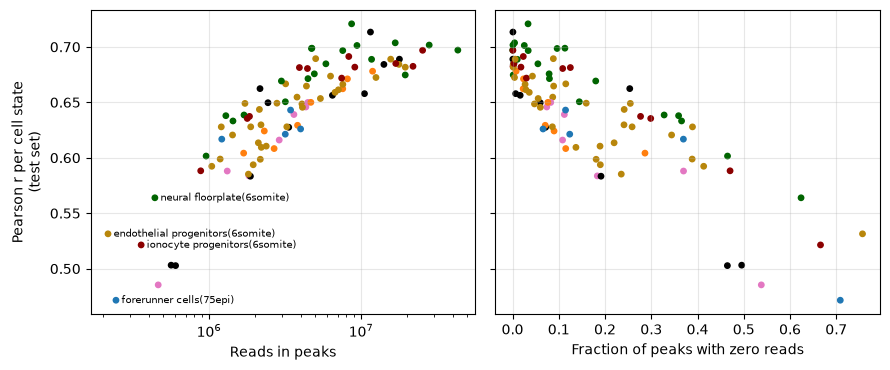

In [8]:
cell_state_pearson_r = metrics_per_cell_state[('combined', 'test')]['pearson_r']
colors = definitions.CELL_STATE_METADATA['lineage'].map(plot.LINEAGE_COLORS)

fig, axes = pyplot.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, col, xlabel in zip(axes, ['reads_in_peaks', 'frac_zero'], ['Reads in peaks', 'Fraction of peaks with zero reads']):
    ax.scatter(depth_df[col], cell_state_pearson_r, c=colors, s=15)
    ax.set_xlabel(xlabel)
    ax.grid(alpha=0.3)
axes[0].set_xscale('log')
axes[0].set_ylabel('Pearson r per cell state\n(test set)')

# Label the cell states with the fewest reads
for cell_state in depth_df['reads_in_peaks'].nsmallest(4).index:
    axes[0].annotate(
        cell_state,
        (depth_df.loc[cell_state, 'reads_in_peaks'], cell_state_pearson_r[cell_state]),
        xytext=(4, 0),
        textcoords='offset points',
        fontsize=7,
        va='center',
    )
fig.tight_layout()
pyplot.show()

## Performance per peak

Distribution of per-peak correlations on the test set of each split and the combined test set. Labels show the median ± interquartile range (IQR).

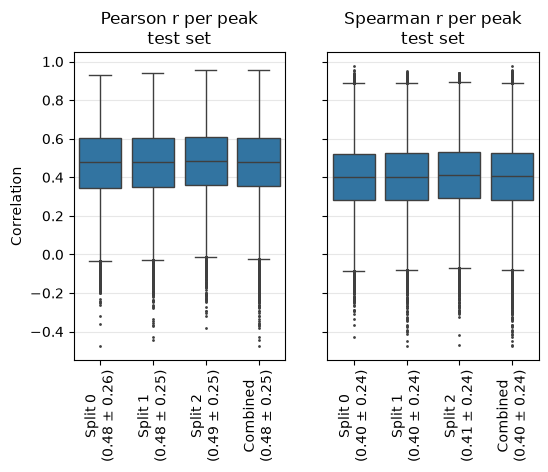

In [9]:
fig, axes = pyplot.subplots(1, 2, figsize=(6, 4), sharey=True)
for ax, metric, metric_label in zip(axes, ['pearson_r', 'spearman_r'], ['Pearson r', 'Spearman r']):
    # Long-format table with one row per split and peak
    metric_df = pandas.concat([
        pandas.DataFrame({'split': split_names[split], metric: metrics_per_peak[(split, 'test')][metric].values})
        for split in splits_to_plot
    ])
    seaborn.boxplot(data=metric_df, x='split', y=metric, fliersize=1, ax=ax)

    # Tick labels with median and IQR
    tick_labels = []
    for split in splits_to_plot:
        vals = metrics_per_peak[(split, 'test')][metric]
        iqr = vals.quantile(0.75) - vals.quantile(0.25)
        tick_labels.append(f'{split_names[split]}\n({vals.median():.2f} ± {iqr:.2f})')
    ax.set_xticks(range(len(tick_labels)))
    ax.set_xticklabels(tick_labels, rotation=90)
    ax.set_xlabel('')
    ax.set_ylabel('Correlation')
    ax.set_title(f'{metric_label} per peak\ntest set')
    ax.grid(axis='y', alpha=0.3)
pyplot.show()

Test set Pearson r of each peak vs. the standard deviation of its measured signal across cell states. Peaks with similar accessibility in all cell states have little variation to predict, so their correlations tend to be lower and more variable.

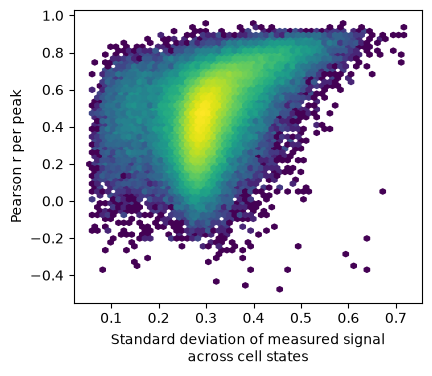

In [10]:
peak_metrics_df = metrics_per_peak[('combined', 'test')]
peak_signal_std = test_signal_df.std(axis=1)
fig, ax = pyplot.subplots(figsize=(4.5, 3.8))
ax.hexbin(peak_signal_std, peak_metrics_df['pearson_r'], gridsize=60, bins='log', cmap='viridis', mincnt=1)
ax.set_xlabel('Standard deviation of measured signal\nacross cell states')
ax.set_ylabel('Pearson r per peak')
pyplot.show()

## Predictions on negative regions

Negative regions are random genomic regions that do not overlap peaks. During training, the model was taught to predict the minimum measured signal for these regions, which is the same in every cell state after quantile normalization. The histogram compares predictions on test negatives and test peaks, pooled across cell states.

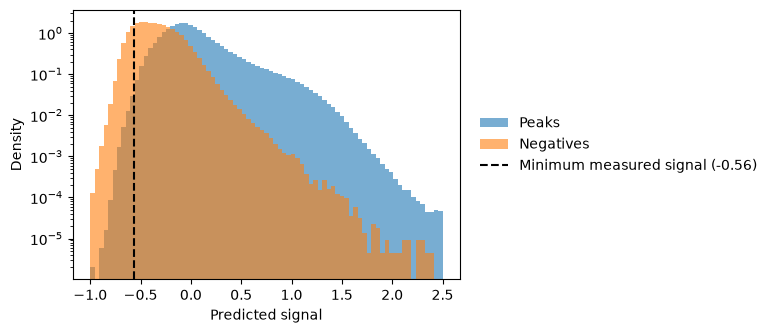

In [11]:
min_signal = signal_df.values.min()
fig, ax = pyplot.subplots(figsize=(5, 3.5))
bins = numpy.linspace(-1, 2.5, 80)
ax.hist(preds[('combined', 'test', 'peaks')].values.ravel(), bins=bins, density=True, alpha=0.6, label='Peaks')
ax.hist(preds[('combined', 'test', 'negatives')].values.ravel(), bins=bins, density=True, alpha=0.6, label='Negatives')
ax.axvline(min_signal, color='k', linestyle='--', label=f'Minimum measured signal ({min_signal:.2f})')
ax.set_xlabel('Predicted signal')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
pyplot.show()